# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

In [25]:
df = pd.read_csv("housing.csv")

# take a look at the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

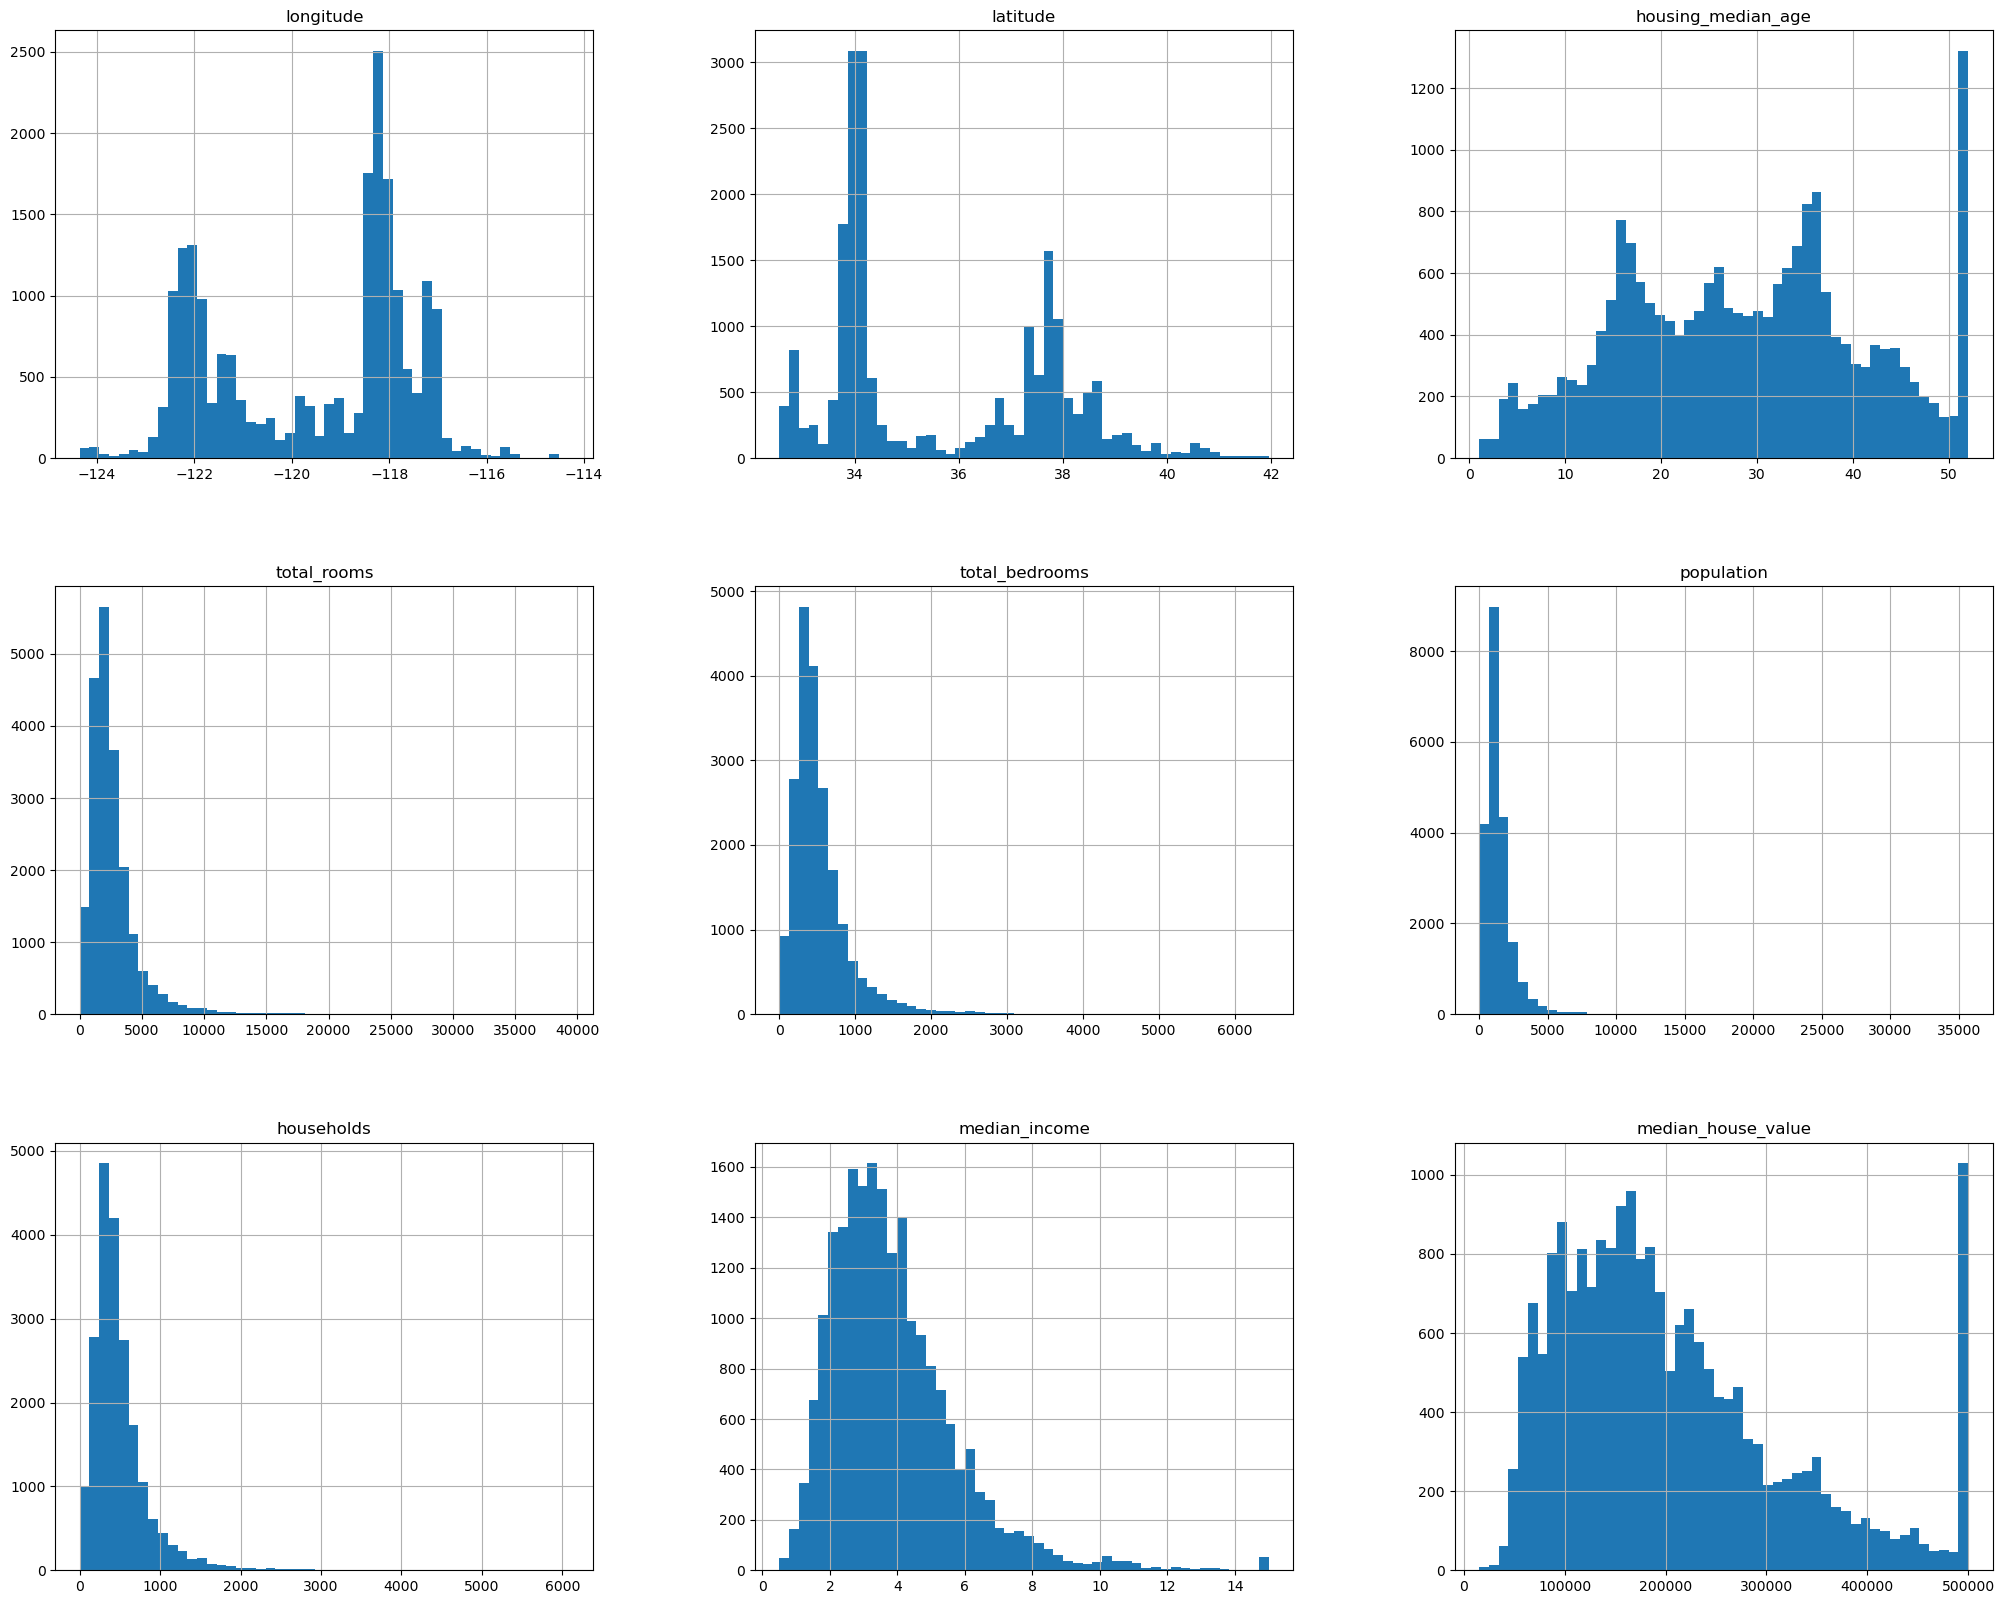

In [5]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(25,20))
plt.show()

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df_drop = df.dropna()

2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [8]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]


In [9]:
df["population_per_household"] = df["population"] / df["households"]


In [10]:
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096


3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [12]:

top2 = df["rooms_per_household"].nlargest(2)

In [13]:
bottom2 = df["rooms_per_household"].nsmallest(2)

In [14]:
top2_bottom2 = pd.concat([top2, bottom2])
print(top2_bottom2)

1914    141.909091
1979    132.533333
5916      0.846154
8219      0.888889
Name: rooms_per_household, dtype: float64


In [15]:
df = df.drop(index=top2_bottom2.index)

# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

Text(0.5, 1.0, 'Distribution of Median House Value')

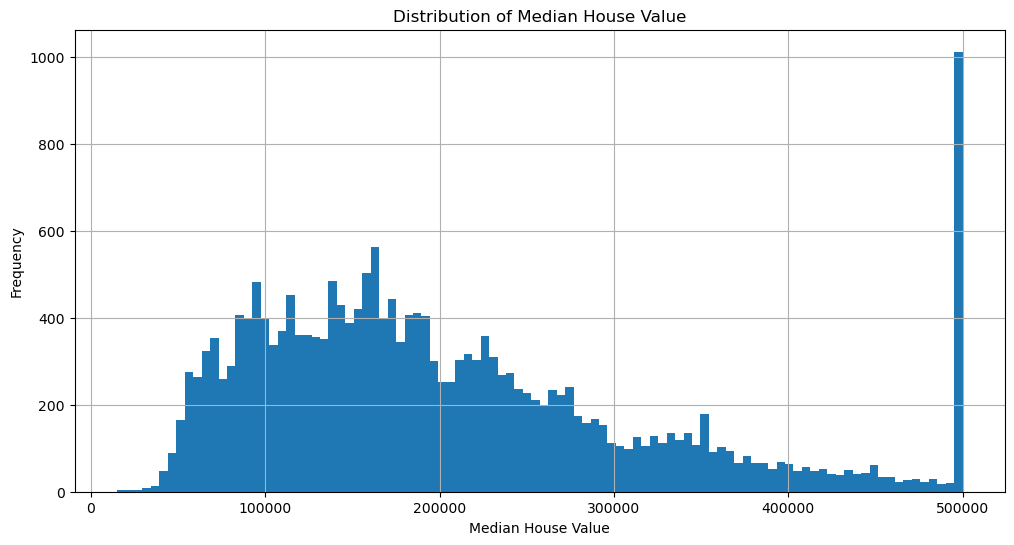

In [26]:
import matplotlib.pyplot as plt

df["median_house_value"].hist(bins=100, figsize=(12,6))
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")


2. Check out what variables correlates the most with "median house value"

In [17]:
df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688369
rooms_per_household         0.171586
total_rooms                 0.134173
housing_median_age          0.105653
households                  0.065927
total_bedrooms              0.049701
population_per_household   -0.023743
population                 -0.024598
longitude                  -0.045911
latitude                   -0.144413
bedrooms_per_room          -0.256741
Name: median_house_value, dtype: float64

3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

Text(0, 0.5, 'Frequency')

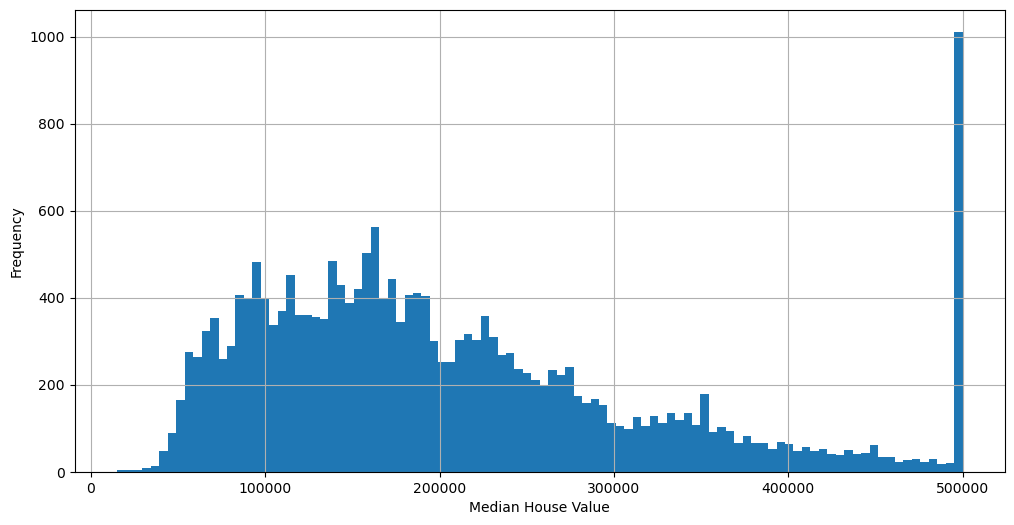

In [27]:
df["median_house_value"].hist(bins=100, figsize=(12,6))
plt.xlabel("Median House Value")
plt.ylabel("Frequency")


4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

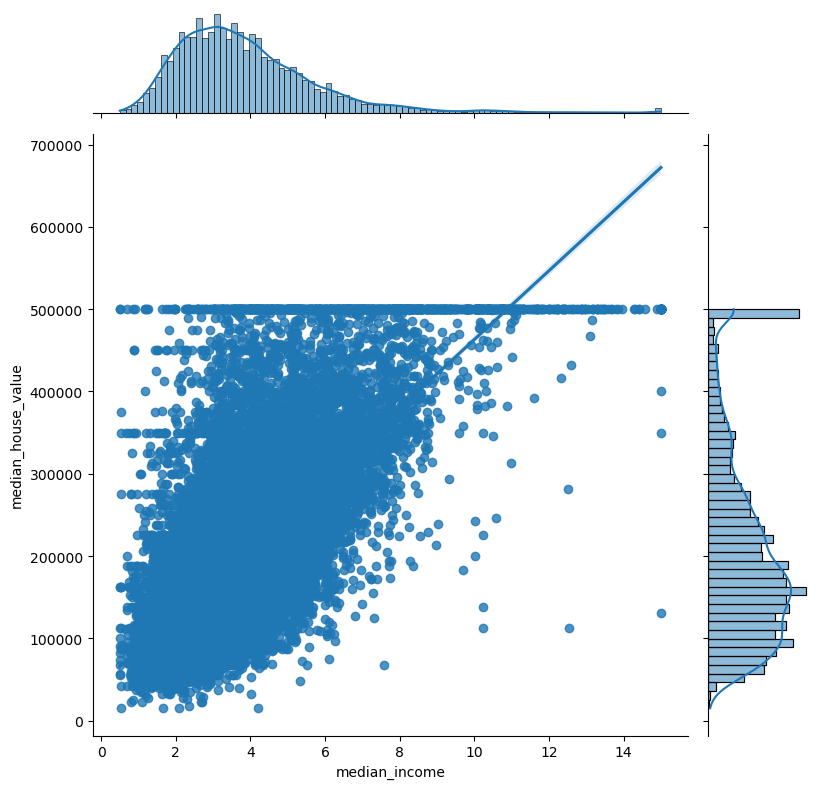

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(
    x="median_income",
    y="median_house_value",
    data=df,
    kind="reg",
    height=8
)
plt.show()

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

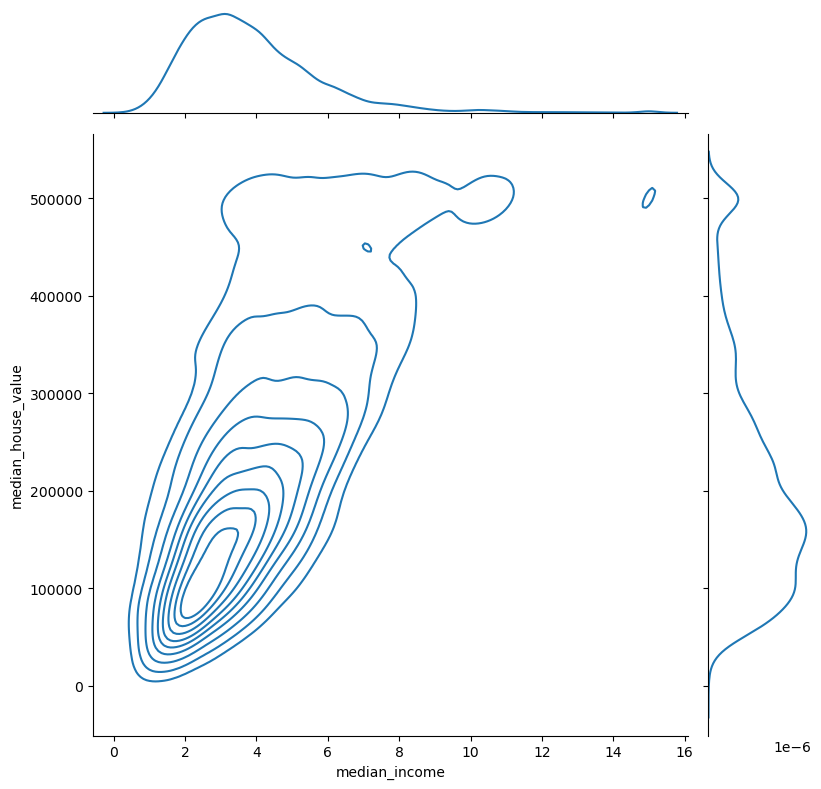

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(
    x="median_income",
    y="median_house_value",
    data=df,
    kind="kde",
    height=8
)
plt.show()

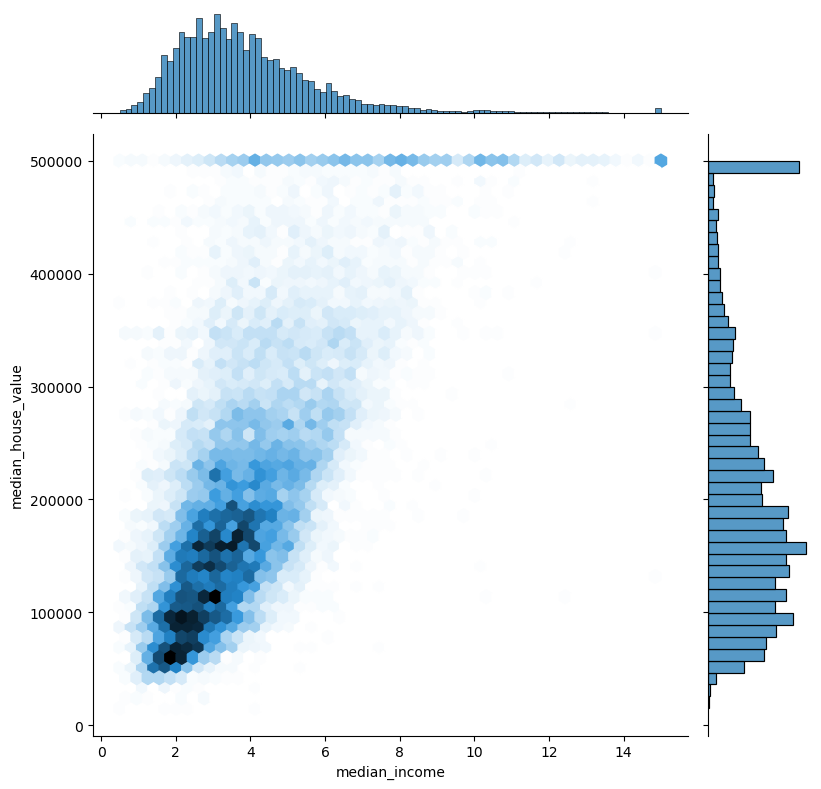

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(
    x="median_income",
    y="median_house_value",
    data=df,
    kind="hex",
    height=8
)
plt.show()

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [31]:
import pandas as pd

bins = [0, 0.25, 0.5, 0.75, 0.95, 1]
labels = ["Low", "Below_Average", "Above_Average", "High", "Very High"]

df["income_cat"] = pd.qcut(
    df["median_income"],
    q=bins,
    labels=labels
)

2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

Text(0, 0.5, 'Count')

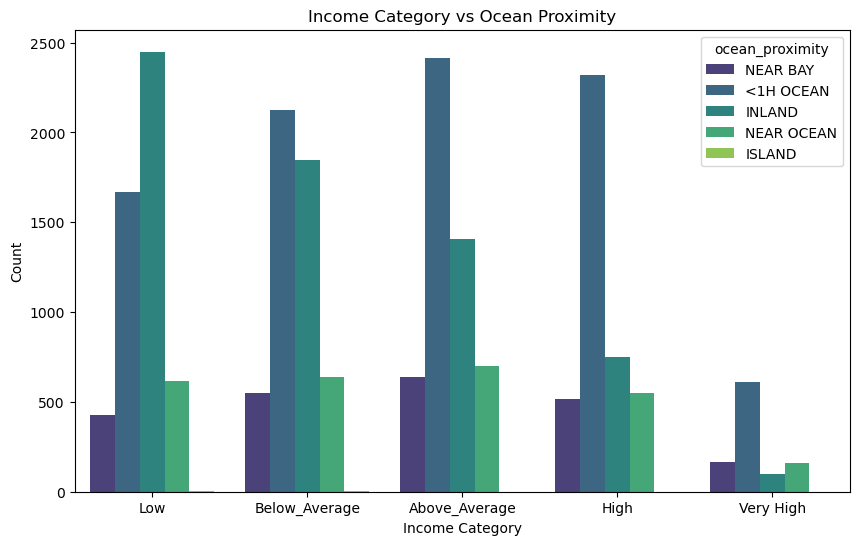

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="income_cat",
    hue="ocean_proximity",
    palette="viridis"
)

plt.title("Income Category vs Ocean Proximity")
plt.xlabel("Income Category")
plt.ylabel("Count")

# The income is higher the nearest to the ocean. 


3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

<Axes: xlabel='income_cat', ylabel='median_house_value'>

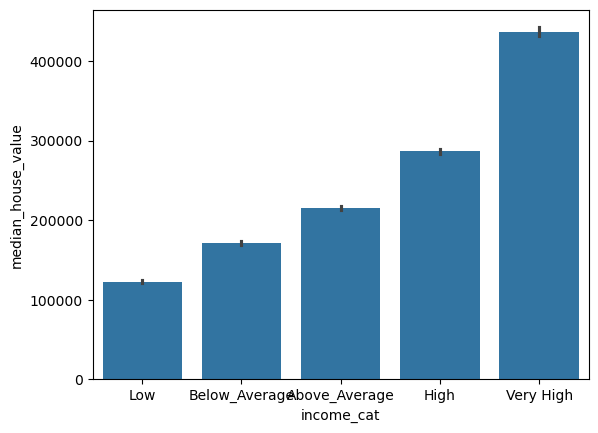

In [40]:

sns.barplot(
    data=df,
    x="income_cat",
    y="median_house_value"
)


<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

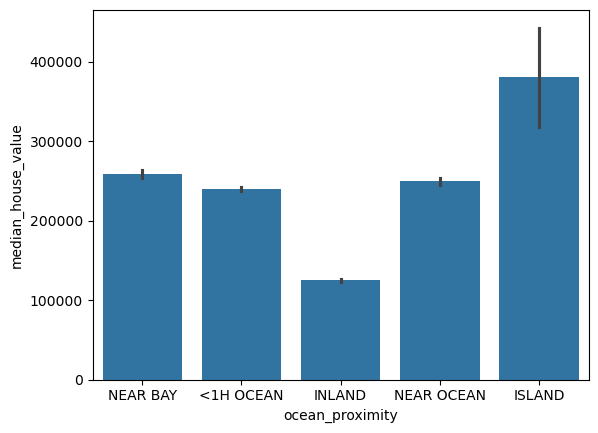

In [41]:

sns.barplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value"
)

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [42]:
pivot_df = pd.crosstab(
    index=df["income_cat"],
    columns=df["ocean_proximity"]
)


pivot_df = pivot_df.drop(columns=["ISLAND"], errors="ignore")

pivot_df

ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,1669,2450,426,614
Below_Average,2125,1847,548,636
Above_Average,2412,1409,637,702
High,2318,749,514,547
Very High,612,96,165,159


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

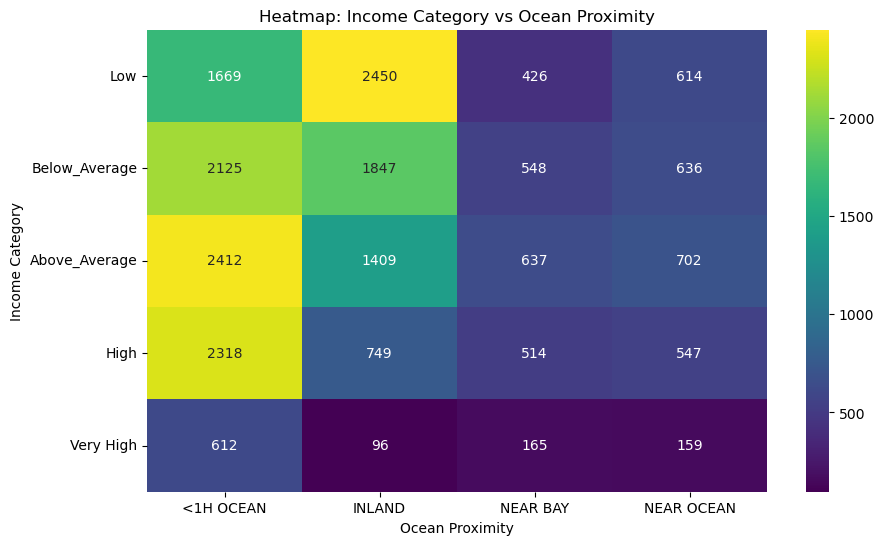

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_df,
    annot=True,          
    fmt="d",             
    cmap="viridis"       
)
plt.title("Heatmap: Income Category vs Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Income Category")
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [49]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [50]:
import scipy.stats as stats

In [104]:
num_cols = ['longitude','latitude','housing_median_age','total_rooms',
            'total_bedrooms','population','households','median_income']

In [105]:

X_num = df[num_cols]
X_num_z = X_num.apply(lambda col: stats.zscore(col, nan_policy='omit'))

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [93]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype='object')

In [110]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [109]:
y = df["median_house_value"]
X = df.drop(columns=["median_house_value"])

In [108]:
print(X.shape)
print(y.shape)
print(X.index.equals(y.index))
print(X.isna().sum().sum())
print(y.isna().sum())

(20640, 13)
(20640,)
True
20640
0


4. Save our predicting variable to `y`.

In [111]:
y = df["median_house_value"]

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [117]:
X = pd.concat([X_num_z, df[['INLAND','ISLAND','NEAR BAY','NEAR OCEAN']]], axis=1)
y = df['median_house_value']

# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   
    random_state=42 
)

In [119]:
X.shape, y.shape

((20640, 12), (20640,))

#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [120]:
X_train.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
INLAND                0
ISLAND                0
NEAR BAY              0
NEAR OCEAN            0
dtype: int64

In [121]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

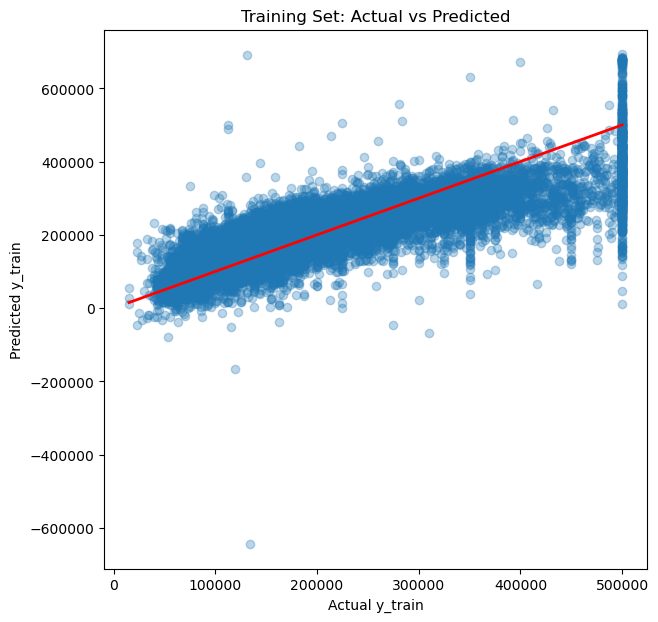

In [122]:
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train)

plt.figure(figsize=(7,7))
plt.scatter(y_train, y_train_pred, alpha=0.3)

plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linewidth=2)

plt.xlabel("Actual y_train")
plt.ylabel("Predicted y_train")
plt.title("Training Set: Actual vs Predicted")
plt.show()

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [123]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred = model.predict(X_train)

mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 4683203783.504253
R²: 0.6496648627123223


#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

In [124]:
y_test_pred = model.predict(X_test)

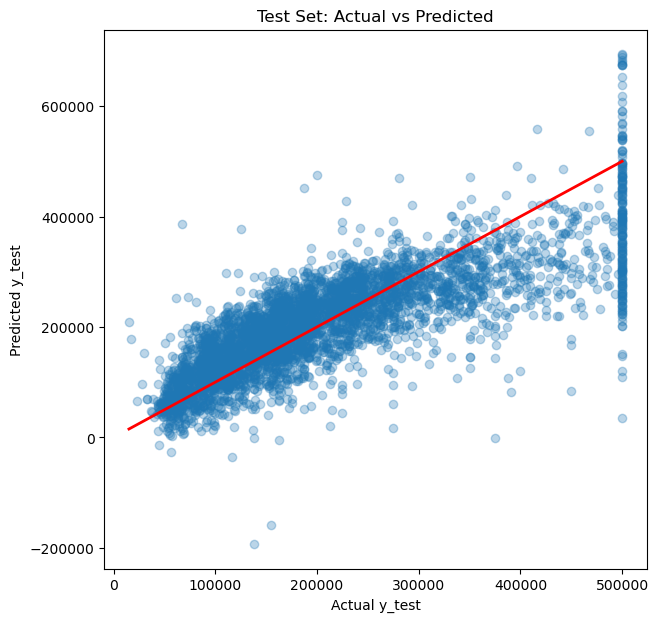

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.3)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual y_test")
plt.ylabel("Predicted y_test")
plt.title("Test Set: Actual vs Predicted")
plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [126]:
from sklearn.metrics import mean_squared_error, r2_score

y_test_pred = model.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Test MSE:", mse_test)
print("Test R²:", r2_test)

Test MSE: 4908476721.156615
Test R²: 0.6254240620553606


3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

In [128]:
import numpy as np

rmse_test = np.sqrt(mse_test)
print("RMSE:", rmse_test)

RMSE: 70060.52184473518


# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [24]:
from sklearn.ensemble import RandomForestRegressor

2. Make prediction on the test data and evaluate you results.